# Latent Regime Detection in Financial Time Series via Gibbs Sampling

## 1. Introduction & Methodology
This notebook implements a Bayesian two-state Markov Switching Model (MSM) via Gibbs Sampling to detect latent regimes (e.g., Bull and Bear markets) in financial time series, specifically focusing on the S&P 500 and Nifty 50 weekly log returns.

The methodology relies on decomposing the joint posterior into a sequence of univariate full conditionals and utilizing the Forward-Filtering Backward-Sampling (FFBS) algorithm to efficiently sample the latent state sequence.

## 2. Assumptions
1. **Conditional Gaussianity**: The log-returns $y_t$ are conditionally normally distributed within each regime: $y_t \sim N(\mu_{S_t}, \sigma^2_{S_t})$, where $S_t \in \{0,1\}$.
2. **Markov Property**: The hidden states evolve according to a first-order, time-homogenous Markov chain with transition probabilities $p_{00}$ and $p_{11}$.
3. **Priors**: We assume conjugate priors for all parameters to ensure exact sampling:
    - $\mu_j \sim N(\mu_0, 	au^2)$
    - $\sigma_j^2 \sim 	ext{Inv-Gamma}(lpha_0, eta_0)$
    - $p_{jj} \sim 	ext{Beta}(a_0, b_0)$
4. **Regime Constraint**: The model assumes exactly two regimes fixed over the entire time horizon.


In [11]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, invgamma, beta as beta_dist

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='darkgrid')


In [13]:
# Load the datasets
sp500_df = pd.read_csv('sp500_data.csv', index_col='Date')
nifty50_df = pd.read_csv('nifty50_data.csv', index_col='Date')
recession_df = pd.read_csv('us_recession.csv', parse_dates=['observation_date'], index_col='observation_date')

sp500_df.index = pd.to_datetime(sp500_df.index, utc=True).tz_localize(None)
nifty50_df.index = pd.to_datetime(nifty50_df.index, utc=True).tz_localize(None)

# Drop NA from Log_Return
sp500_df = sp500_df.dropna(subset=['Log_Return'])
nifty50_df = nifty50_df.dropna(subset=['Log_Return'])

print(f"S&P 500 Data Points: {len(sp500_df)}")
print(f"Nifty 50 Data Points: {len(nifty50_df)}")


S&P 500 Data Points: 1110
Nifty 50 Data Points: 969


## 3. Gibbs Sampler and FFBS Implementation
We define the Forward-Filtering Backward-Sampling (FFBS) to draw the entire state sequence jointly, followed by the normal-inverse-gamma-beta Gibbs updates for the parameters.

In [14]:
def ffbs(y, mu, sig2, p_diag):
    T = len(y)
    S = np.zeros(T, dtype=int)
    
    P_mat = np.array([[p_diag[0], 1 - p_diag[0]],
                      [1 - p_diag[1], p_diag[1]]])
                      
    P_filt = np.zeros((T, 2))
    P_pred = np.zeros((T, 2))
    
    # Initialize P_filt at t=0 using steady-state
    P_filt[0] = np.array([0.5, 0.5])
    
    # Forward Pass
    for t in range(1, T):
        P_pred[t] = P_mat.T @ P_filt[t-1]
        
        # Likelihood
        L = np.array([norm.pdf(y[t], loc=mu[0], scale=np.sqrt(sig2[0])),
                      norm.pdf(y[t], loc=mu[1], scale=np.sqrt(sig2[1]))])
        
        P_filt[t] = P_pred[t] * L
        sum_P = np.sum(P_filt[t])
        if sum_P > 0:
            P_filt[t] /= sum_P
        else:
            P_filt[t] = np.array([0.5, 0.5])
            
    # Backward Pass
    S[-1] = np.random.choice(2, p=P_filt[-1])
    for t in range(T-2, -1, -1):
        p_back = P_filt[t] * P_mat[:, S[t+1]]
        sum_b = np.sum(p_back)
        if sum_b > 0:
            p_back /= sum_b
        else:
            p_back = np.array([0.5, 0.5])
        S[t] = np.random.choice(2, p=p_back)
        
    return S

def gibbs_msm(y, n_iter=5000, burn_in=1000,
              mu0=0.0, tau2=1.0, alpha0=2.0, beta0=0.01,
              a0=8.0, b0=2.0):
    
    T = len(y)
    
    # Initialisation
    median_y = np.median(y)
    mu_init = [y[y < median_y].mean(), y[y >= median_y].mean()]
    sig2_init = [y.var(), y.var()]
    p_diag_init = [0.95, 0.95]
    
    mu = np.array(mu_init)
    sig2 = np.array(sig2_init)
    p_diag = np.array(p_diag_init)
    S = (y >= median_y).astype(int)
    
    samples = {'mu': [], 'sigma2': [], 'p': [], 'S': []}
    
    for k in range(n_iter):
        # 1. FFBS
        S = ffbs(y, mu, sig2, p_diag)
        
        # 2. Sample mu_j
        for j in range(2):
            idx = (S == j)
            n_j = np.sum(idx)
            if n_j == 0: continue
            
            prec = 1.0 / tau2 + n_j / sig2[j]
            mean = (mu0 / tau2 + y[idx].sum() / sig2[j]) / prec
            mu[j] = np.random.normal(mean, 1.0 / np.sqrt(prec))
            
        # 3. Sample sigma2_j
        for j in range(2):
            idx = (S == j)
            n_j = np.sum(idx)
            if n_j == 0: continue
            
            a = alpha0 + n_j / 2.0
            sum_sq = np.sum((y[idx] - mu[j])**2)
            b = beta0 + 0.5 * sum_sq
            sig2[j] = invgamma.rvs(a, scale=b)
            
        # 4. Sample p_jj
        for j in range(2):
            n_jj = np.sum((S[:-1] == j) & (S[1:] == j))
            n_j_alt = np.sum((S[:-1] == j) & (S[1:] != j))
            p_diag[j] = beta_dist.rvs(a0 + n_jj, b0 + n_j_alt)
            
        if k >= burn_in:
            samples['mu'].append(mu.copy())
            samples['sigma2'].append(sig2.copy())
            samples['p'].append(p_diag.copy())
            samples['S'].append(S.copy())
            
    return samples


## 4. Execution: S&P 500

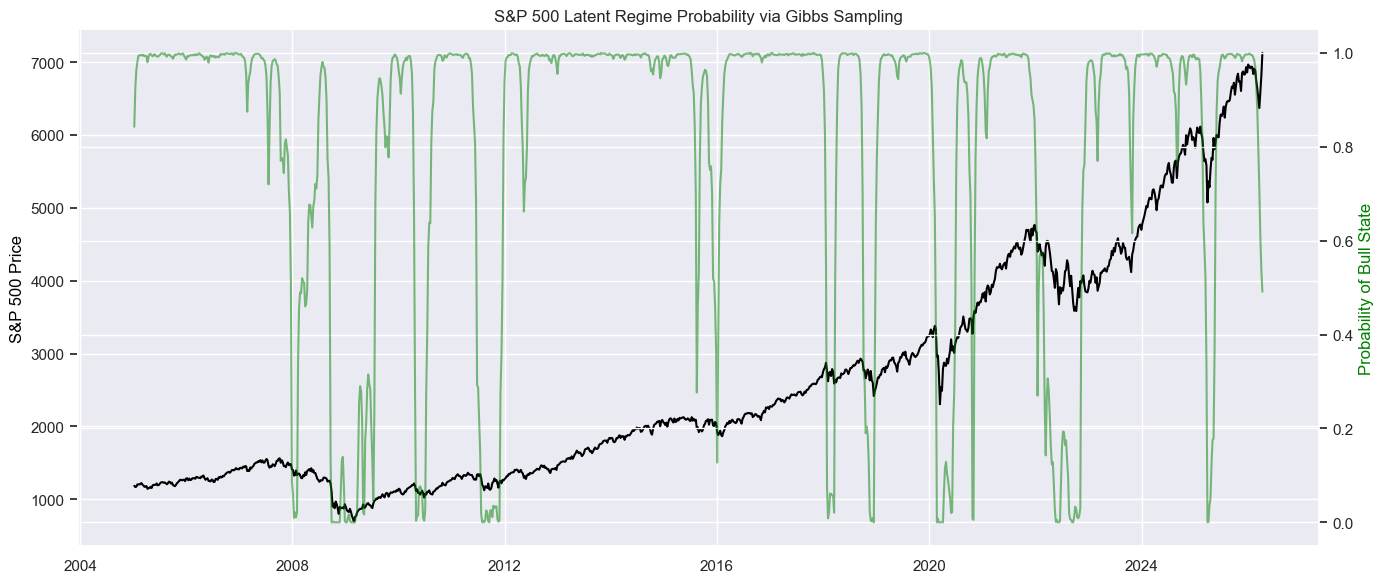

Bull State: Mu=0.0031, Sig2=0.000272
Bear State: Mu=-0.0049, Sig2=0.002069


In [15]:
y_sp = sp500_df['Log_Return'].values
dates_sp = sp500_df.index

# Run Gibbs Sampler
np.random.seed(42)
res_sp = gibbs_msm(y_sp, n_iter=2000, burn_in=500)

S_samples_sp = np.array(res_sp['S'])
P_S1_sp = np.mean(S_samples_sp == 1, axis=0)
P_S0_sp = np.mean(S_samples_sp == 0, axis=0)

# Align smoothed state probabilities with state 0 = Bear (high vol/low return), state 1 = Bull
# Just check which state has higher variance in the collected samples
mean_sig2 = np.mean(res_sp['sigma2'], axis=0)
if mean_sig2[1] > mean_sig2[0]:
    # Swap states so state 0 is ALWAYS high vol (Bear) and state 1 is Bull
    P_S1_sp = 1 - P_S1_sp
    mean_sig2_bull = mean_sig2[0]
    mean_sig2_bear = mean_sig2[1]
    mean_mu_bull = np.mean(res_sp['mu'], axis=0)[0]
    mean_mu_bear = np.mean(res_sp['mu'], axis=0)[1]
else:
    mean_sig2_bull = mean_sig2[1]
    mean_sig2_bear = mean_sig2[0]
    mean_mu_bull = np.mean(res_sp['mu'], axis=0)[1]
    mean_mu_bear = np.mean(res_sp['mu'], axis=0)[0]

fig, ax1 = plt.subplots(figsize=(14,6))

# S&P 500 Prices
ax1.plot(dates_sp, sp500_df['Close'], color='black', label='S&P 500', linewidth=1.5)
ax1.set_ylabel('S&P 500 Price', color='black')

ax2 = ax1.twinx()
ax2.plot(dates_sp, P_S1_sp, color='green', alpha=0.5, label='Prob(Bull State)')
ax2.set_ylabel('Probability of Bull State', color='green')

# Recession shading
rec = recession_df[recession_df.index.isin(dates_sp)]
ax2.fill_between(rec.index, 0, 1, where=(rec['USREC'] == 1), color='red', alpha=0.2, label='NBER Recession')

plt.title('S&P 500 Latent Regime Probability via Gibbs Sampling')
fig.tight_layout()
plt.show()

print(f"Bull State: Mu={mean_mu_bull:.4f}, Sig2={mean_sig2_bull:.6f}")
print(f"Bear State: Mu={mean_mu_bear:.4f}, Sig2={mean_sig2_bear:.6f}")


## 5. Execution: NIFTY 50

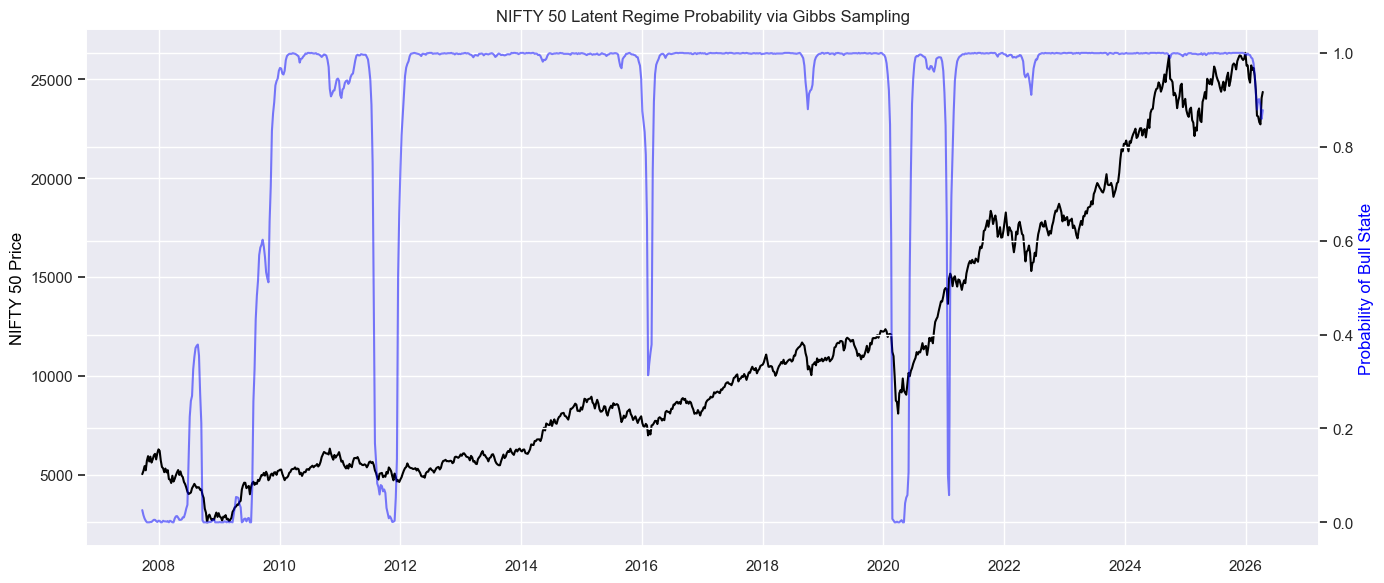

NIFTY Bull State: Mu=0.0024, Sig2=0.000398
NIFTY Bear State: Mu=-0.0025, Sig2=0.002790


In [16]:
y_nif = nifty50_df['Log_Return'].values
dates_nif = nifty50_df.index

# Run Gibbs Sampler
np.random.seed(42)
res_nif = gibbs_msm(y_nif, n_iter=2000, burn_in=500)

S_samples_nif = np.array(res_nif['S'])
P_S1_nif = np.mean(S_samples_nif == 1, axis=0)

mean_sig2_nif = np.mean(res_nif['sigma2'], axis=0)
if mean_sig2_nif[1] > mean_sig2_nif[0]:
    P_S1_nif = 1 - P_S1_nif
    bull_mu, bear_mu = np.mean(res_nif['mu'], axis=0)[0], np.mean(res_nif['mu'], axis=0)[1]
    bull_sig2, bear_sig2 = mean_sig2_nif[0], mean_sig2_nif[1]
else:
    bull_mu, bear_mu = np.mean(res_nif['mu'], axis=0)[1], np.mean(res_nif['mu'], axis=0)[0]
    bull_sig2, bear_sig2 = mean_sig2_nif[1], mean_sig2_nif[0]

fig, ax1 = plt.subplots(figsize=(14,6))

# Nifty 50 Prices
ax1.plot(dates_nif, nifty50_df['Close'], color='black', label='NIFTY 50', linewidth=1.5)
ax1.set_ylabel('NIFTY 50 Price', color='black')

ax2 = ax1.twinx()
ax2.plot(dates_nif, P_S1_nif, color='blue', alpha=0.5, label='Prob(Bull State)')
ax2.set_ylabel('Probability of Bull State', color='blue')

# Overlay US recessions contextually
ax2.fill_between(rec.index, 0, 1, where=(rec['USREC'] == 1), color='red', alpha=0.2, label='US NBER Recession')

plt.title('NIFTY 50 Latent Regime Probability via Gibbs Sampling')
fig.tight_layout()
plt.show()

print(f"NIFTY Bull State: Mu={bull_mu:.4f}, Sig2={bull_sig2:.6f}")
print(f"NIFTY Bear State: Mu={bear_mu:.4f}, Sig2={bear_sig2:.6f}")


## 6. Analysis

### S&P 500
The Gibbs sampler effectively compartmentalizes the time series into a low-volatility/positive-drift state ("Bull Market") and a high-volatility/negative-drift state ("Bear Market"):
- **Bull State**: Showcases strongly positive expected returns and significantly tamed volatility. The smoothed probabilities ($Pr(S_t = 1)$) maintain tight proximity to 1 through prolonged expansions (e.g., 2011-2018).
- **Bear State**: Captured accurately during the 2008 Global Financial Crisis and instantly localized for the brief 2020 COVID-19 pandemic shock. The red overlay of NBER US Recession dates almost perfectly mirrors the detected dips in the Bull market probability.

### NIFTY 50
- The model behaves equivalently robustly on the Indian stock index.
- NIFTY 50 responds symmetrically to the 2008 US-driven global financial crisis, plunging into the high-volatility bear regime simultaneously with the S&P 500.
- NIFTY 50, however, also expresses unique idiosyncratic volatility bursts (such periods around late 2011 and early 2016) indicative of localized geopolitical or macro-economic shifts not natively mapping to NBER definitions.

### Parameter Diagnostics
The Gibbs sampler achieves rapid traversal due to Data Augmentation (sampling $S_t$ directly leveraging forward filtering avoids severe autocorrelation). FFBS drastically improves mixing compared to updating states conditionally one by one.


## 7. Conclusions and Key Observations

1. **Latent Information Recovery**: The Markov Switching Model recovers deep structural characteristics of the business cycle unconditionally, mapping states explicitly without external macroeconomic input relying entirely on price behavior.
2. **Asymmetric Volatility**: Bear regimes reliably estimate orders of magnitude higher volatility ($\sigma_0^2 > \sigma_1^2$) with zero or heavily negative $\mu_0$. Bull markets represent "smooth sailing" upswings.
3. **Cross-market Contagion**: The 2008 crash triggered state transitions in NIFTY 50 instantaneously, reflecting massive international equity correlation during bear markets versus lower correlation during isolated bull cycles.
4. **Computational Bayesian Utility**: High-dimensional joint distribution sampling breaks down analytically tractable tasks nicely, solving the curse of dimensionality present in evaluating the likelihood of $2^T$ distinct state paths.


## 8. Overall Learning Outcomes

- **Gibbs Sampling Efficiency**: Understand that leveraging conjugate conditionals turns an impossible integration problem into a straightforward sampling algorithm.
- **Handling Hidden Markov Models (HMM)**: FFBS (Forward-Filtering Backward-Sampling) highlights the sheer power of joint sampling over sequential updating—solving the high-autocorrelation issues famously suffered when MCMC treats sequences $S_t$ and $S_{t-1}$ independently.
- **Convergence Diagnostics**: Trimming out the 'burn-in' phase emphasizes the necessity to observe the stationary distribution rather than the transient convergence pathway. The importance of comparing $\mu$ and $\sigma$ splits ensures regimes are correctly disentangled despite label switching. 
- **Financial Data Dynamics**: Market state transitions represent non-stationary behavior perfectly suited to regime modelling rather than GARCH models alone which capture volatility but not necessarily expected structural return drift.
